# 使用Pytorch构建神经网络

>在1.中我们已经学习了如何从零开始构建神经网络，神经网络通常包括输入层、隐藏层、输出层、激活函数、损失函数和学习率等基本组件。在3.中，我们将学习如何在简单数据集上使用 PyTorch 构建神经网络，利用张量对象操作和梯度值计算更新网络权重。

## 1.Pytorch构建神经网络初体验  
### 1.1 使用Pytorch构建神经网络  
为了介绍如何使用 PyTorch 构建神经网络，我们将尝试解决两个数字的相加问题。  

整体链路：  
输入 x  
  ↓   
Linear 层 (W, b)  
  ↓  
输出 ŷ  
  ↓  
计算 Loss  
  ↓  
反向传播（算梯度）  
  ↓  
optimizer  
  ↓  
通过 parameters()  
  ↓  
更新 W, b


1. 初始化数据集，定义输入(x)和输出(y)值：

In [94]:
import torch
x = [[1,2],[3,4],[5,6],[7,8]]
y = [[3],[7],[11],[15]]


在初始化的输入和输出变量中，输入中的每个列表的值之和就是输出列表中对应的值。

2. 将输入列表转化成张量对象：

In [95]:
X = torch.tensor(x).float()
Y = torch.tensor(y).float()

在以上代码中，将张量对象转换为浮点对象。此外，将输入 ( X ) 和输出 ( Y ) 数据点注册到 device 中：

In [96]:
device = 'cpu'
X = X.to(device)
Y = Y.to(device)

3. 定义神经网络架构  
导入torch.nn模块用于构建神经网络模型

In [97]:
from torch import nn

- 创建神经网络架构类 MyNeuralNet，继承自 nn.Module，nn.Module 是所有神经网络模块的基类：  
- 在类中，使用 init 方法初始化神经网络的所有组件，调用 super().\_\_init\_\_() 确保类继承 nn.Module：  
- 使用以下代码，通过指定 super().\_\_init\_\_() 可以利用为 nn.Module 编写的所有预构建函数，初始化的组件将用于 MyNeuralNet 类中的不同方法。

In [98]:
class MyNeuralNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.input_to_hidden_layer = nn.Linear(2,8)#输入层：2个神经元 隐藏层：8个神经元
        self.hidden_layer_activation = nn.ReLU()#激活函数
        self.hidden_to_output_layer = nn.Linear(8,1)#隐藏层：8个神经元 输出层：1个神经元

- 定义神经网络中的网络层：  
  a. 一个全连接层 (self.input_to_hidden_layer)，    
  b. 使用 ReLU 激活函数 (self.hidden_layer_activation)，  
  c. 最后仍是一个全连接层 (self.hidden_to_output_layer)。

将初始化后的神经网络组件连接在一起，并定义网络的前向传播方法 forward：

In [99]:
class MyNeuralNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.input_to_hidden_layer = nn.Linear(2,8)#输入层：2个神经元 隐藏层：8个神经元
        self.hidden_layer_activation = nn.ReLU()#激活函数
        self.hidden_to_output_layer = nn.Linear(8,1)#隐藏层：8个神经元 输出层：1个神经元
    def forward (self, x):
        x = self.input_to_hidden_layer(x)
        x = self.hidden_layer_activation(x)
        x = self.hidden_to_output_layer(x)
        return x

>必须使用 forward 作为前向传播的函数名，因为 PyTorch 保留此函数作为执行前向传播的方法，使用其他名称都会引发错误。

通过打印 nn.Linear 方法的输出了解函数作用：

In [100]:
print(nn.Linear(2, 7))

Linear(in_features=2, out_features=7, bias=True)


>在以上代码中，全连接层以 2 个值作为输入并输出 7 个值，且包含与之关联的偏置参数。

4. 通过执行以下代码访问每个神经网络组件的初始权重 
    
- 创建 MyNeuralNet 类对象的实例并将其注册到 device：

In [101]:
mynet = MyNeuralNet().to(device)

- 可以通过类似代码访问每一层的权重和偏置： 

In [102]:
print(mynet.input_to_hidden_layer.weight)

Parameter containing:
tensor([[ 0.3263,  0.0612],
        [ 0.2188, -0.5037],
        [ 0.5748,  0.5096],
        [-0.5536, -0.2816],
        [ 0.0090, -0.6721],
        [ 0.5005, -0.6951],
        [-0.6052,  0.3616],
        [ 0.4366,  0.1334]], requires_grad=True)


每次执行时输出的值并不相同，因为神经网络每次都使用随机值进行初始化。如果希望每次在执行相同代码时保持相同输出，则需要在创建类对象的实例之前使用 Torch 中的 manual_seed 方法指定随机种子 torch.manual_seed(0)

5. 可以通过以下代码获得神经网络的所有参数：

In [103]:
mynet.parameters()

<generator object Module.parameters at 0x000002A0386277B0>

以上代码会返回一个生成器对象，最后通过生成器循环获取参数：

In [104]:
for param in mynet.parameters():
    print(param)

Parameter containing:
tensor([[ 0.3263,  0.0612],
        [ 0.2188, -0.5037],
        [ 0.5748,  0.5096],
        [-0.5536, -0.2816],
        [ 0.0090, -0.6721],
        [ 0.5005, -0.6951],
        [-0.6052,  0.3616],
        [ 0.4366,  0.1334]], requires_grad=True)
Parameter containing:
tensor([-0.6822,  0.5285, -0.6634, -0.1451,  0.1327,  0.5266,  0.3877,  0.0038],
       requires_grad=True)
Parameter containing:
tensor([[-0.3350,  0.1430,  0.2687,  0.1150,  0.0070,  0.3279, -0.1631,  0.3388]],
       requires_grad=True)
Parameter containing:
tensor([-0.0399], requires_grad=True)


该模型已将这些张量注册为跟踪前向和反向传播所必需的特殊对象，在 init 方法中定义 nn 神经网络层时，它会自动创建相应的张量并同时进行注册，也可以使用 nn.parameter(<tensor>) 函数手动注册这些参数。因此，本节定义的神经网络类 myNeuralNet 等价于以下代码：

In [105]:
class MyNeuralNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.input_to_hidden_layer = nn.parameter(torch.rand(2,8))
        self.hidden_layer_activation = nn.ReLU()
        self.hidden_to_output_layer =nn.parameter(torch.rand(8,1))
    def forward(self,x):
        x = x @ self.input_to_hidden_layer
        x = self.hidden_layer_activation(x)
        x = x @ self.hidden_to_output_layer
        return x

6. 定义损失函数，由于需要预测连续输出，因此使用均方误差作为损失函数：

In [106]:
loss_func = nn.MSELoss()

通过将输入值传递给神经网络对象，然后计算给定输入的损失函数值：

In [107]:
_Y = mynet(X)
loss_value = loss_func(_Y, Y)
print(loss_value)


tensor(68.6235, grad_fn=<MseLossBackward0>)


在以上代码中，mynet(X) 根据给定输入通过神经网络计算输出值，loss_func 函数计算对应于神经网络预测 (_Y) 和实际值 (Y) 的 MSELoss 值。需要注意的是，根据 PyTorch 约定，在计算损失时，我们总是首先传入预测结果，然后传入实际标记值。

7. 定义用于降低损失值的优化器  
>优化器的输入是与神经网络相对应的参数(权重和偏差)以及更新权重时的学习率。我们使用随机梯度下降 (Stochastic Gradient Descent, SGD)。从 torch.optim 模块中导入 SGD 方法，然后将神经网络对象 (mynet) 和学习率 (lr) 作为参数传递给 SGD 方法：

In [108]:
from torch.optim import SGD
opt = SGD(mynet.parameters(), lr = 0.001)

8. 一个 epoch 训练过程包含以下步骤：  
- 计算给定输入和输出对应的损失值  
- 计算参数对应的梯度  
- 根据参数的学习率和梯度更新权重  
- 更新权重后，确保在下一个 epoch 计算梯度之前刷新上一步中计算的梯度

In [109]:
opt.zero_grad()
'''
作用：把模型中所有可训练参数的梯度清零。
原因：PyTorch 的梯度是累加的，如果不清零，每次 backward() 会把梯度加到上一次的值上，会导致梯度计算错误。
'''
loss_value = loss_func(mynet(X),Y)
loss_value.backward()#计算完之后，参数的 .grad 属性里就存了梯度。
opt.step()#作用：根据刚刚计算出的梯度，更新模型的参数。w=w−learning_rate * grad(SGD)

使用 for 循环重复执行上述步骤。在以下代码中，执行 50 个 epoch，此外，在 loss_history 列表中存储每个 epoch 中的损失值

In [110]:
loss_history = []
for _ in range(50):
    opt.zero_grad()
    loss_value = loss_func(mynet(X), Y)
    loss_value.backward()
    opt.step()
    loss_history.append(loss_value.item())#.item() 把 标量张量 转成 Python 浮点数（float）。

绘制损失随 epoch 的变化情况：

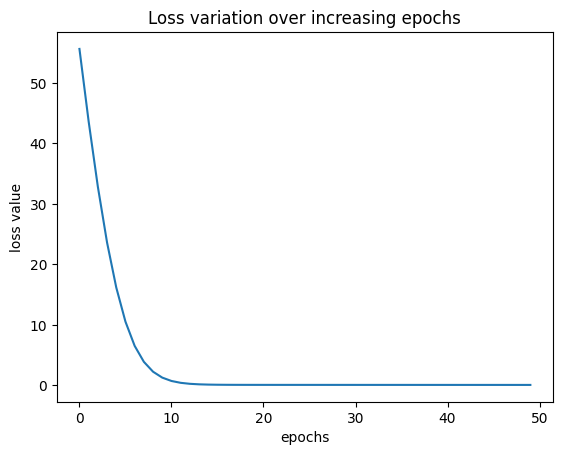

In [111]:
import matplotlib.pyplot as plt
plt.plot(loss_history)
plt.title('Loss variation over increasing epochs')
plt.xlabel('epochs')
plt.ylabel('loss value')
plt.show()

### 1.2 神经网络数据加载  
批大小 (batch size) 是神经网络中的重要超参数，批大小是指计算损失值或更新权重时考虑的数据样本数。假设数据集中有数百万个数据样本，一次将所有数据点用于一次权重更新并非最佳选择，因为内存可能无法容纳如此多数据。使用抽样样本可以充分代表数据，批大小可以用于获取具有足够代表性的多个数据样本。在这里，我们指定计算权重梯度时要考虑的批大小以更新权重，然后计算更新后的损失值。  

1. 导入用于加载数据和处理数据集的方法：

In [112]:
from torch.utils.data import Dataset, DataLoader
import torch
import torch.nn as nn

2. 导入数据，将数据转换为浮点数，并将它们注册到相应设备中：

In [113]:
x = [[1,2],[3,4],[5,6],[7,8]]
y = [[3],[7],[11],[15]]

X = torch.tensor(x).float()
Y = torch.tensor(y).float()

device = 'cpu'
X = X.to(device)
Y = Y.to(device)

3.创建数据集类 MyDataset：  
- 在 MyDataset 类中，存储数据信息以便可以将一批 (batch) 数据点捆绑在一起(使用 DataLoader)，
- 通过一次前向和反向传播更新权重。​
- 定义 init 方法，该方法接受输入和输出对并将它们转换为 Torch 浮点对象：

In [114]:
class MyDataset(Dataset):
    def __init__(self,x,y):
        self.x = x.clone().detach() # torch.tensor(x).float()
        self.y = y.clone().detach() # torch.tensor(y).float()
    def __len__(self):
        return len(self.x)
    def __getitem__(self, ix):
        return self.x[ix], self.y[ix]

指定输入数据集的长度 (\_\_len\_\_)：

In [115]:
def __len__(self):
    return len(self.x)

getitem 方法用于获取指定数据样本：

In [116]:
def __getitem__(self, ix):
    return self.x[ix], self.y[ix]#ix 表示要从数据集中获取的数据索引。

4. 创建自定义类的实例：

In [117]:
ds = MyDataset(X, Y)

5. 通过 DataLoader 传递数据集实例，从原始输入输出张量对象中获取 batch_size 个数据点：

In [118]:
dl = DataLoader(ds, batch_size=2, shuffle=True)

循环遍历 dl 获取批数据信息：

In [119]:
for x, y in dl:
    print(x, y)

tensor([[5., 6.],
        [7., 8.]]) tensor([[11.],
        [15.]])
tensor([[1., 2.],
        [3., 4.]]) tensor([[3.],
        [7.]])


6. 定义神经网络类

In [120]:
class MyNeuralNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.input_to_hidden_layer = nn.Linear(2, 8)
        self.hidden_layer_activation = nn.ReLU()
        self.hidden_to_output_layer =nn.Linear(8,1)
    def forward(self, x):
        x = self.input_to_hidden_layer(x)
        x = self.hidden_layer_activation(x)
        x = self.hidden_to_output_layer(x)
        return x        

7. 定义模型对象 (mynet)、损失函数 (loss_func) 和优化器 (opt)：

In [121]:
mynet = MyNeuralNet().to(device)
loss_func = nn.MSELoss()
from torch.optim import SGD
opt = SGD(mynet.parameters(), lr = 0.001)

8. 最后，循环遍历批数据点以最小化损失值

In [122]:
import time
loss_history = []
start = time.time()
for _ in range(50):
    for data in dl:
        x, y = data
        opt.zero_grad()
        loss_value = loss_func(mynet(x), y)
        loss_value.backward()
        opt.step()
        loss_history.append(loss_value.item())
    end = time.time()
    print(end - start)

0.0010001659393310547
0.002001523971557617
0.003000974655151367
0.003000974655151367
0.003999948501586914
0.003999948501586914
0.005000591278076172
0.00600123405456543
0.00600123405456543
0.00600123405456543
0.007307291030883789
0.00830698013305664
0.00830698013305664
0.009306907653808594
0.009306907653808594
0.010307550430297852
0.010307550430297852
0.01130819320678711
0.01130819320678711
0.012307167053222656
0.012307167053222656
0.013306856155395508
0.013306856155395508
0.014307975769042969
0.014307975769042969
0.015307903289794922
0.015307903289794922
0.016306638717651367
0.016306638717651367
0.01730656623840332
0.01730656623840332
0.01830744743347168
0.01830744743347168
0.019307374954223633
0.019307374954223633
0.020306825637817383
0.020306825637817383
0.021306514739990234
0.021306514739990234
0.022307634353637695
0.022307634353637695
0.023307323455810547
0.023307323455810547
0.0243070125579834
0.0243070125579834
0.0243070125579834
0.02530646324157715
0.02530646324157715
0.02730464

虽然以上代码与上一小节中使用的代码非常相似，但与上一小节相比，每个 epoch 更新权重的次数变为原来的 2 倍，因为本节中使用的批大小为 2，而上一小节中的批大小为 4 (即一次使用全部数据点)。

### 1.3 模型测试  
在上一小节中，我们学习了如何在已知数据点上拟合模型。在本节中，我们将学习如何利用上一小节训练的 mynet 模型中定义的前向传播方法 forward 来预测模型没有见过的数据点(测试数据)。  

1. 创建用于模型测试的数据点：

In [123]:
val_x = [[10,11]]

2. 将新数据点转换为张量浮点对象并注册到device中：

In [124]:
val_x = torch.tensor(val_x).float().to(device)

3. 通过训练好的神经网络 (mynet) 传递张量对象，与通过模型执行前向传播的用法相同：

In [125]:
print(mynet(val_x))

tensor([[20.4283]], grad_fn=<AddmmBackward0>)


以上代码返回模型对输入数据点的预测输出值。

### 1.4 获取中间层的值  
在实际应用中，我们可能需要获取神经网络的中间层值，例如风格迁移和迁移学习等，PyTorch 提供了两种方式获取神经网络中间值。  

- 一种方法是直接调用神经网络层，将它们直接当作函数使用

In [126]:
print(mynet.hidden_layer_activation(mynet.input_to_hidden_layer(X)))

tensor([[ 0.9943,  0.0000,  0.0000,  0.0000,  3.1554,  1.6285,  0.0000,  0.0000],
        [ 1.2217,  0.0000,  0.0000,  0.0000,  6.4232,  3.3698,  0.0000,  0.0000],
        [ 1.4491,  0.0000,  0.0000,  0.0000,  9.6909,  5.1111,  0.0000,  0.0000],
        [ 1.6766,  0.0000,  0.0000,  0.0000, 12.9586,  6.8523,  0.0000,  0.0000]],
       grad_fn=<ReluBackward0>)


- 另一种方法是在 forward 方法中指定想要查看的网络层，虽然以下代码与上一小节中的 MyNeuralNet 类基本相同，但 forward 方法不仅返回输出，还返回激活后的隐藏层值 (hidden2)：

In [127]:
class MyNeuralNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.input_to_hidden_layer = nn.Linear(2,8)
        self.hidden_layer_activation = nn.ReLU()
        self.hidden_to_output_layer = nn.Linear(8,1)
    def forward(self, x):
        hidden1 = self.input_to_hidden_layer(x)
        hidden2 = self.hidden_layer_activation(hidden1)
        x = self.hidden_to_output_layer(hidden2)
        return x, hidden2

通过使用以下代码访问隐藏层值，mynet 的第 0 个索引输出是网络前向传播的最终输出，而第 1 个索引输出是隐藏层激活后的值：

In [128]:
print(mynet(X)[1])

tensor([7.2438], grad_fn=<SelectBackward0>)


## 2.使用Sequential类构建神经网络  
我们已经学习了如何通过定义一个类来构建神经网络，在该类中定义了层以及层之间的连接方式。然而，除非需要构建一个复杂的网络，否则，只需要利用 Sequential 类并指定层和层堆叠的顺序即可搭建神经网络，本节继续使用简单数据集训练神经网络。  

1. 导入相关库并定义使用的设备：

In [129]:
import torch
import torch.nn as nn
import numpy as np
from torch.utils.data import Dataset, DataLoader
device = 'cpu'

2. 定义数据集与数据集类(MyDataset):

In [130]:
x = [[1,2],[3,4],[5,6],[7,8]]
y = [[3],[7],[11],[15]]

class MyDataset(Dataset):
    def __init__(self, x, y):
        self.x = torch.tensor(x).float().to(device)
        self.y = torch.tensor(y).float().to(device)
    def __getitem__(self, index):
        return self.x[index], self.y[index]
    def __len__(self):
        return len(self.x)

3.  定义数据集 (ds) 和数据加载器 (dl) 对象：

In [131]:
ds = MyDataset(x, y)
dl = DataLoader(ds, batch_size=2, shuffle=True)

4. 使用 nn 模块中 Sequential 类定义模型架构:

In [132]:
model = nn.Sequential(
    nn.Linear(2, 8),
    nn.ReLU(),
    nn.Linear(8, 1)
).to(device)

在以上代码中，我们定义了与上小节相同的网络架构，nn.Linear 接受二维输入并为每个数据点提供八维输出，nn.ReLU 在八维输出之上执行 ReLU 激活，最后，使用 nn.Linear 接受八维输入并得到一维输出。

5. 打印模型的摘要 (summary)，查看模型架构信息。  

- 为了查看模型摘要，需要使用 pip 安装 torchsummary 库：

In [133]:
pip install torchsummary

Note: you may need to restart the kernel to use updated packages.


安装完成后，导入库 torchsummary：

In [134]:
from torchsummary import summary

打印模型摘要，函数接受模型名称及模型输入大小(需要使用整数元组)作为参数：

In [135]:
print(summary(model, (2,),device=str(device)))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1                    [-1, 8]              24
              ReLU-2                    [-1, 8]               0
            Linear-3                    [-1, 1]               9
Total params: 33
Trainable params: 33
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.00
Estimated Total Size (MB): 0.00
----------------------------------------------------------------
None


以第一层输出为例，其形状为 (-1, 8)，其中 -1 表示 batch size，8 表示对于每个数据点会得到一个 8 维输出，得到形状为 batch size x 8 的输出。

6. 接下来，定义损失函数 (loss_func) 和优化器 (opt) 并训练模型：

In [136]:
loss_func = nn.MSELoss()
from torch.optim import SGD
opt = SGD(model.parameters(), lr = 0.001)
import time
loss_history = []
start = time.time()
for _ in range(50):
    for ix, iy in dl:
        opt.zero_grad()
        loss_value = loss_func(model(ix),iy)
        loss_value.backward()
        opt.step()
        loss_history.append(loss_value.item())

end = time.time()
print(end - start)

0.033501386642456055


7. 训练模型后，在验证数据集上预测值。

In [137]:
val = [[8,9],[10,11],[1.5,2.5]]
val = torch.tensor(val).float()
print(model(val.to(device)))

tensor([[17.1822],
        [21.3150],
        [ 3.7387]], grad_fn=<AddmmBackward0>)


## 3. Pytorch模型的保存和加载  
神经网络模型处理的一个重要方面是在训练后保存和加载模型，保存模型后，我们可以利用已经训练好的模型中进行推断，只需要加载已经训练过的模型，而无需再次对其进行训练。  
### 3.1 模型保存所需组件  
首先了解保存神经网络模型所需的完整组件：
- 每个张量(参数)的唯一名称(键)
- 网络中张量间的连接的方式
- 每个张量的值(权重/偏置值)  
  
第一个组件是在定义的 init 阶段处理的，而第二个组件是在前向计算方法定义期间处理的。默认情况下，张量中的值在 init 阶段随机初始化，但加载预训练模型时我们需要加载一组在训练模型时学习到的固定权重值，并将每个值与特定名称相关联。  
### 3.2 模型状态  
model.state_dict() 可以用于了解保存和加载 PyTorch 模型的工作原理，model.state_dict() 中的字典 (OrderedDict) 对应于模型的参数名称(键)及其值(权重和偏置值)，state 指的是模型的当前快照，返回的输出中，键是模型网络层的名称，值对应于这些层的权重


In [138]:
print(model.state_dict())

OrderedDict([('0.weight', tensor([[ 0.1055, -0.2014],
        [-0.4838,  0.0788],
        [ 0.0256, -0.2478],
        [-0.2941,  0.4063],
        [-0.2267, -0.5429],
        [-0.4514,  0.6747],
        [ 0.9092,  0.7937],
        [ 0.5608,  0.3998]])), ('0.bias', tensor([-0.6805, -0.4377, -0.3907, -0.6589,  0.6232, -0.3282, -0.2189, -0.6113])), ('2.weight', tensor([[-0.2633, -0.1778,  0.2184, -0.1428,  0.2479,  0.1991,  1.0372,  0.2828]])), ('2.bias', tensor([0.0096]))])


### 3.3模型保存  
使用 torch.save(model.state_dict(), 'mymodel.pth') 可以将模型以 Python 序列化格式保存在磁盘上，其中 mymodel.pth 表示文件名。在调用 torch.save 之前最好将模型传输到 CPU 中，将张量保存为 CPU 张量有助于将模型加载到任意机器上：

In [139]:
save_path = '使用Pytorch构建神经网络.pth'
torch.save(model.state_dict(), save_path)

### 3.4 模型加载  
加载模型首先需要初始化模型，然后从 state_dict 中加载权重：  

1. 使用与训练时相同的代码创建一个空模型：

In [140]:
model = nn.Sequential(
    nn.Linear(2, 8),
    nn.ReLU(),
    nn.Linear(8, 1)
).to(device)

2. 从磁盘加载模型并反序列化以创建一个 OrderedDict 值：

In [141]:
state_dict = torch.load('使用Pytorch构建神经网络.pth')

C:\Users\Admin\AppData\Local\Temp\ipykernel_28296\301797124.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load('使用Pytorch构建神经网络.pth')


3. 加载 state_dict 到模型中，并将其注册到 device 中，执行预测任务：

In [142]:
model.load_state_dict(state_dict)
model.to(device)

val = [[8,9],[10,11],[1.5,2.5]]
val = torch.tensor(val).float()
model(val.to(device))

tensor([[17.1822],
        [21.3150],
        [ 3.7387]], grad_fn=<AddmmBackward0>)

## 小结  
在本节中，我们使用 PyTorch 在简单数据集上构建了一个神经网络，训练神经网络来映射输入和输出，并通过执行反向传播来更新权重值以最小化损失值，并利用 Sequential 类简化网络构建过程；介绍了获取网络中间值的常用方法，以及如何使用 save、load 方法保存和加载模型，以避免再次训练模型。​
​